In [1]:
from pathlib import Path
from textalloc import allocate
import json
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import yaml

from _configs.country_config import *
from _configs.files_config import *
from _configs.run_config import *

from _utils.utils import *

In [2]:
input_data = yaml.safe_load((Path(VALIDATION_RUN_INPUTS_DIR)/"input_validation.yml").read_text(encoding="utf-8"))
# input_data = yaml.safe_load((Path(VALIDATION_RUN_INPUTS_DIR)/"input_population_bins_beta_zero_pop_0.25.yml").read_text(encoding="utf-8"))


population_scale_from_input_yml = input_data["population_demographic"]["artificial_rescaling_of_population_size"]
starting_date = input_data["simulation_timeframe"]["starting_date"]
birth_rate_from_config = input_data["population_demographic"]["birth_rate"]
public_pct = input_data["strategy_parameters"]["strategy_db"][8]["start_distribution"][0]
private_pct = input_data["strategy_parameters"]["strategy_db"][8]["start_distribution"][1]

print(f"Population scale: {population_scale_from_input_yml}")
print(f"Starting date: {starting_date}")
print(f"Birth rate: {birth_rate_from_config}")
print(f"Public percentage: {public_pct}")
print(f"Private percentage: {private_pct}")

# 1) Use the original dict
country_dict = {
    "population_scale": population_scale_from_input_yml,
    }
country_json = json.dumps(country_dict, ensure_ascii=False)
# 3) Attribute-style access (SimpleNamespace)
from types import SimpleNamespace
country = json.loads(country_json, object_hook=lambda d: SimpleNamespace(**d))

exp_path = validation_path
output_path = Path(exp_path) / "output"
analysis_path = Path(exp_path) / "analysis"
os.makedirs(analysis_path, exist_ok=True)

print("\ndata_path:", data_path)
print("output_path:", output_path)
print("analysis_path:", analysis_path)

Population scale: 0.25
Starting date: 2011/1/1
Birth rate: 0.0335
Public percentage: 0.445
Private percentage: 0.555

data_path: DATA
output_path: validation_runs/validation_init_pop_21.12M.asc_0.25_population_scale_multiple_pattern_20_replicates/output
analysis_path: validation_runs/validation_init_pop_21.12M.asc_0.25_population_scale_multiple_pattern_20_replicates/analysis


## PfPR

In [3]:
output_path_obj = Path(output_path)
if not output_path_obj.exists() or not output_path_obj.is_dir():
    raise NotADirectoryError(f"Path {output_path} is not a valid directory.")
db_files = list(output_path_obj.glob("*.db"))
if len(db_files) == 0:
    raise FileNotFoundError(f"No .db files found in directory {output_path}.")

agg_population = pd.DataFrame(columns=["monthly_data_id", "unit_id", "population"])
agg_treatment = pd.DataFrame(columns=["monthly_data_id", "unit_id", "treatments"])
agg_clinical_episodes = pd.DataFrame(columns=["monthly_data_id", "unit_id", "clinical_episodes"])
agg_prevalence_2_to_10 = pd.DataFrame(columns=["monthly_data_id", "unit_id", "pfpr_2to10"])
agg_clinical_episodes_2_to_10 = pd.DataFrame(columns=["monthly_data_id", "unit_id", "clinical_episodes_2_to_10"])
agg_prevalence_under_5 = pd.DataFrame(columns=["monthly_data_id", "unit_id", "pfpr_under5"])
agg_clinical_episodes_under_5 = pd.DataFrame(columns=["monthly_data_id", "unit_id", "clinical_episodes_under5"])

rep = 0
for file in output_path_obj.glob("*.db"):
    data = get_table(file, "monthly_site_data_district")
    clinical_episodes_2_to_10 = data[
        [
            "monthly_data_id",
            "unit_id",
            "clinical_episodes_by_age_class_2_3",
            "clinical_episodes_by_age_class_3_4",
            "clinical_episodes_by_age_class_4_5",
            "clinical_episodes_by_age_class_5_6",
            "clinical_episodes_by_age_class_6_7",
            "clinical_episodes_by_age_class_7_8",
            "clinical_episodes_by_age_class_8_9",
            "clinical_episodes_by_age_class_9_10",
        ]
    ].copy()
    clinical_episodes_2_to_10["clinical_episodes_2_to_10"] = clinical_episodes_2_to_10[
        [
            "clinical_episodes_by_age_class_2_3",
            "clinical_episodes_by_age_class_3_4",
            "clinical_episodes_by_age_class_4_5",
            "clinical_episodes_by_age_class_5_6",
            "clinical_episodes_by_age_class_6_7",
            "clinical_episodes_by_age_class_7_8",
            "clinical_episodes_by_age_class_8_9",
            "clinical_episodes_by_age_class_9_10",
        ]
    ].sum(axis=1)
    clinical_episodes_under_5 = data[
        [
            "monthly_data_id",
            "unit_id",
            "clinical_episodes_by_age_class_0_1",
            "clinical_episodes_by_age_class_1_2",
            "clinical_episodes_by_age_class_2_3",
            "clinical_episodes_by_age_class_3_4",
            "clinical_episodes_by_age_class_4_5",
        ]
    ].copy()
    clinical_episodes_under_5["clinical_episodes_under5"] = clinical_episodes_under_5[
        [
            "clinical_episodes_by_age_class_0_1",
            "clinical_episodes_by_age_class_1_2",
            "clinical_episodes_by_age_class_2_3",
            "clinical_episodes_by_age_class_3_4",
            "clinical_episodes_by_age_class_4_5",
        ]
    ].sum(axis=1)
    
    # Add a column to the agg_* data frames from data
    try:
        agg_population = agg_population.merge(
            data[["monthly_data_id", "unit_id", "population"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_treatment = agg_treatment.merge(
            data[["monthly_data_id", "unit_id", "treatments"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_clinical_episodes = agg_clinical_episodes.merge(
            data[["monthly_data_id", "unit_id", "clinical_episodes"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_prevalence_2_to_10 = agg_prevalence_2_to_10.merge(
            data[["monthly_data_id", "unit_id", "pfpr_2to10"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        
        agg_clinical_episodes_2_to_10 = agg_clinical_episodes_2_to_10.merge(
            clinical_episodes_2_to_10[["monthly_data_id", "unit_id", "clinical_episodes_2_to_10"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_prevalence_under_5 = agg_prevalence_under_5.merge(
            data[["monthly_data_id", "unit_id", "pfpr_under5"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_clinical_episodes_under_5 = agg_clinical_episodes_under_5.merge(
            clinical_episodes_under_5[["monthly_data_id", "unit_id", "clinical_episodes_under5"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
    except Exception as e:
        error(f"Error processing replicate {rep}: {e}")
    rep += 1
    
agg_population = agg_population.drop(columns=["population"])
agg_treatment = agg_treatment.drop(columns=["treatments"])
agg_clinical_episodes = agg_clinical_episodes.drop(columns=["clinical_episodes"])
agg_prevalence_2_to_10 = agg_prevalence_2_to_10.drop(columns=["pfpr_2to10"])
agg_clinical_episodes_2_to_10 = agg_clinical_episodes_2_to_10.drop(columns=["clinical_episodes_2_to_10"])
agg_prevalence_under_5 = agg_prevalence_under_5.drop(columns=["pfpr_under5"])
agg_clinical_episodes_under_5 = agg_clinical_episodes_under_5.drop(columns=["clinical_episodes_under5"])

agg_prevalence_2_to_10.to_csv(f"{analysis_path}/agg_prevalence_2_to_10.csv", index=False)
agg_clinical_episodes_2_to_10.to_csv(f"{analysis_path}/agg_clinical_episodes_2_to_10.csv", index=False)
agg_prevalence_under_5.to_csv(f"{analysis_path}/agg_prevalence_under_5.csv", index=False)
agg_clinical_episodes_under_5.to_csv(f"{analysis_path}/agg_clinical_episodes_under_5.csv", index=False)
agg_population.to_csv(f"{analysis_path}/agg_population.csv", index=False)
agg_treatment.to_csv(f"{analysis_path}/agg_treatment.csv", index=False)
agg_clinical_episodes.to_csv(f"{analysis_path}/agg_clinical_episodes.csv", index=False)

In [4]:
# agg_clinical_episodes.tail(24)
# agg_clinical_episodes = agg_clinical_episodes.sort_values("unit_id", ascending=False).reset_index(drop=True)
# unit_id_to_inspect = 6
# agg_clinical_episodes.loc[
#     agg_clinical_episodes["unit_id"] == unit_id_to_inspect
# ].sort_values("monthly_data_id")
agg_clinical_episodes.tail(24)

,monthly_data_id,unit_id,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2,clinical_episodes_3,clinical_episodes_4,clinical_episodes_5,clinical_episodes_6,clinical_episodes_7,...,clinical_episodes_10,clinical_episodes_11,clinical_episodes_12,clinical_episodes_13,clinical_episodes_14,clinical_episodes_15,clinical_episodes_16,clinical_episodes_17,clinical_episodes_18,clinical_episodes_19
918,154,1,87892,87813,88042,88201,88438,88274,88125,87991,...,88266,88090,88154,88444,88570,88150,88390,88085,88054,88370
919,154,2,46691,46593,46628,46367,46105,46131,45939,46126,...,46261,46132,45968,46639,46529,46396,46623,46380,46544,46451
920,154,3,51419,51882,51601,51115,51775,51739,51625,51565,...,52007,51671,51738,51809,51801,51888,52023,52115,51443,51718
921,154,4,39113,39134,39071,39091,38917,39385,39064,39289,...,39366,39553,39453,39198,39556,39076,38947,38684,38967,39435
922,154,5,63230,63056,63166,63569,63541,63118,62810,63700,...,62891,63554,64165,63919,63802,62928,63249,63035,63353,63541
923,154,6,42963,43015,43331,42738,42512,43302,42880,42706,...,42880,42845,42753,43107,43031,42850,42836,42763,42978,43113
924,155,1,86564,86312,86700,86947,87121,86236,85878,86059,...,86810,86268,86041,87115,86796,86240,86424,86275,86420,86834
925,155,2,46090,46751,46445,46298,46387,46460,45990,46373,...,46555,46467,46272,46579,46332,46120,46467,45906,46277,46535
926,155,3,49032,48532,49482,48798,49094,49053,48871,48949,...,48955,48728,49111,48787,48919,48803,49374,48912,49057,49227
927,155,4,37850,37974,38206,38206,37859,38115,38098,38091,...,38252,37900,38338,38159,38375,38244,38063,38358,38361,38183


In [5]:
# months = np.sort(agg_clinical_episodes["monthly_data_id"].unique())
# end_month = int(months[-1]) + 1
# start_month = end_month - 12

# start month should be january of incidence comparision year assuming month 0 is january of initial year
incidence_comparison_start_month = (incidence_comparison_year - initial_year) * 12
incidence_comparison_end_month = incidence_comparison_start_month + 12

print(f"Start month for incidence comparison: {incidence_comparison_start_month}, End month: {incidence_comparison_end_month}")
print(f"Start date: {initial_year + incidence_comparison_start_month // 12}-{incidence_comparison_start_month % 12 + 1:02d}")
print(f"End date: {initial_year + incidence_comparison_end_month // 12}-{incidence_comparison_end_month % 12 + 1:02d}")

Start month for incidence comparison: 120, End month: 132
Start date: 2021-01
End date: 2022-01


In [6]:
prevalence_comparison_start_month = (calibration_year - initial_year) * 12
prevalence_comparison_end_month = prevalence_comparison_start_month + 12

print(f"Start month for calibration comparison: {prevalence_comparison_start_month}, End month: {prevalence_comparison_end_month}")
print(f"Start date: {initial_year + prevalence_comparison_start_month // 12}-{prevalence_comparison_start_month % 12 + 1:02d}")
print(f"End date: {initial_year + prevalence_comparison_end_month // 12}-{prevalence_comparison_end_month % 12 + 1:02d}")

Start month for calibration comparison: 156, End month: 168
Start date: 2024-01
End date: 2025-01


In [7]:
agg_clinical_episodes = pd.read_csv(f"{analysis_path}/agg_clinical_episodes.csv")
agg_clinical_episodes_2_to_10 = pd.read_csv(f"{analysis_path}/agg_clinical_episodes_2_to_10.csv")
agg_clinical_episodes_under_5 = pd.read_csv(f"{analysis_path}/agg_clinical_episodes_under_5.csv")
agg_prevalence_2_to_10 = pd.read_csv(f"{analysis_path}/agg_prevalence_2_to_10.csv")
agg_prevalence_under_5 = pd.read_csv(f"{analysis_path}/agg_prevalence_under_5.csv")
agg_population = pd.read_csv(f"{analysis_path}/agg_population.csv")
agg_treatment = pd.read_csv(f"{analysis_path}/agg_treatment.csv")

In [8]:
agg_clinical_episodes.tail(6)

,monthly_data_id,unit_id,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2,clinical_episodes_3,clinical_episodes_4,clinical_episodes_5,clinical_episodes_6,clinical_episodes_7,...,clinical_episodes_10,clinical_episodes_11,clinical_episodes_12,clinical_episodes_13,clinical_episodes_14,clinical_episodes_15,clinical_episodes_16,clinical_episodes_17,clinical_episodes_18,clinical_episodes_19
936,157,1,73715,72140,73502,72992,73596,73495,73190,73542,...,72955,73605,73108,73864,73314,73172,73523,73654,73356,73959
937,157,2,44505,44795,44642,44201,44046,44420,44046,43990,...,44358,44743,44433,44869,44240,44157,44026,44048,44224,43930
938,157,3,35642,35476,36164,35991,36208,35882,35843,35977,...,35379,35938,35692,35801,36034,35800,36113,35995,35662,36113
939,157,4,31026,30530,30586,31065,30574,30798,30430,30797,...,31095,31063,30812,30838,30798,30702,30799,30662,31097,30957
940,157,5,65363,65526,64989,65198,65211,64791,65047,65306,...,65146,65615,65464,65750,65682,65279,65528,64762,64891,65068
941,157,6,39635,39938,39883,39556,39487,39756,39983,39929,...,40151,40105,40069,39976,40071,39879,39334,39611,39762,39765


In [9]:
# data_at_calib = agg_clinical_episodes.loc[agg_population["monthly_data_id"].between(incidence_comparison_start_month, incidence_comparison_end_month, inclusive="left")].copy()
data_at_calib = agg_clinical_episodes.loc[
    agg_clinical_episodes["monthly_data_id"].between(
        incidence_comparison_start_month,
        incidence_comparison_end_month,
        inclusive="left"
    )
].copy()
data_at_calib

,monthly_data_id,unit_id,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2,clinical_episodes_3,clinical_episodes_4,clinical_episodes_5,clinical_episodes_6,clinical_episodes_7,...,clinical_episodes_10,clinical_episodes_11,clinical_episodes_12,clinical_episodes_13,clinical_episodes_14,clinical_episodes_15,clinical_episodes_16,clinical_episodes_17,clinical_episodes_18,clinical_episodes_19
714,120,1,73344,73171,73195,72739,72761,72922,73091,73694,...,73443,73458,73469,73581,73706,73559,73473,72833,73636,73208
715,120,2,41448,41384,41603,41595,41346,42152,41364,40903,...,41722,41688,41737,41558,41068,41559,41429,41586,41167,41450
716,120,3,38312,38528,38663,38849,38624,38689,38676,38990,...,38542,38746,39210,38748,38484,38614,38678,38790,38605,38729
717,120,4,31740,31783,31717,31824,31796,31929,32015,31725,...,31886,31827,32040,31680,31286,31520,31437,31716,32092,31843
718,120,5,60478,60621,59850,60127,60595,59953,60502,60476,...,60754,60164,60819,60173,59933,60063,60461,60615,60617,60047
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
781,131,2,44489,44939,44900,45215,44591,44691,44769,45168,...,44813,45203,45291,44693,44816,44732,44959,44967,44850,44738
782,131,3,47668,47572,47365,47180,47499,46829,47611,47106,...,47236,47546,47062,47224,47683,47509,47411,47977,47127,47068
783,131,4,37417,36581,36953,37255,36474,36769,37181,37130,...,36807,36485,36894,36677,36977,36955,36891,37036,37065,37100
784,131,5,64127,63517,64095,63093,63330,63232,63603,63333,...,62958,63816,63466,63299,62953,63555,63915,63354,63661,63254


In [10]:
# data_at_calib_sum_1_year = data_at_calib.groupby("unit_id").sum().reset_index()
# data_at_calib_sum_1_year

In [11]:
# data_at_calib_mean_all_rep_1_year = data_at_calib_sum_1_year.copy().drop(columns=["monthly_data_id"]).mean(axis=1)
# data_at_calib_mean_all_rep_1_year

In [12]:
# data_at_calib_mean_all_rep_1_year.sum()
agg_treatment.head(18)

,monthly_data_id,unit_id,treatments_0,treatments_1,treatments_2,treatments_3,treatments_4,treatments_5,treatments_6,treatments_7,...,treatments_10,treatments_11,treatments_12,treatments_13,treatments_14,treatments_15,treatments_16,treatments_17,treatments_18,treatments_19
0,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,4,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,5,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,1,6,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,2,1,238423,237451,237789,237502,237916,238377,238836,238996,...,237286,237701,238649,237821,237649,238985,236810,237673,238005,237043
7,2,2,134035,134623,133556,135131,134668,134582,133977,134203,...,134438,134491,134380,134379,134544,133905,134192,134291,134635,134566
8,2,3,100022,99531,99829,100112,100423,99997,100322,99755,...,99725,99309,99884,100656,99630,100368,100102,100273,100043,100510
9,2,4,72234,71996,72015,72450,72395,72317,72727,71989,...,72042,72670,71902,72881,71561,72534,72138,72097,72243,72287


In [13]:
''' Groups the treatment data by unit_id and sums the total treatments across the specified year (start month to end month) '''
total_treatments_in_incidence_comparison_year_by_unit_id = (
    agg_treatment.loc[agg_treatment["monthly_data_id"].between(incidence_comparison_start_month, incidence_comparison_end_month, inclusive="left")]
    .copy()
    .groupby("unit_id")
    .sum()
)
total_treatments_in_incidence_comparison_year_by_unit_id

,monthly_data_id,treatments_0,treatments_1,treatments_2,treatments_3,treatments_4,treatments_5,treatments_6,treatments_7,treatments_8,...,treatments_10,treatments_11,treatments_12,treatments_13,treatments_14,treatments_15,treatments_16,treatments_17,treatments_18,treatments_19
unit_id,,,,,,,,,,,,,,,,,,,,,
1,1506,529184,527330,529337,527022,524581,527766,526881,528892,527968,...,526639,528291,530744,526761,526772,528020,528146,527073,525846,530839
2,1506,260525,260706,261102,261820,260292,260659,262486,261552,260397,...,260949,261287,261681,261718,260689,260362,260666,261673,259821,260813
3,1506,251126,250852,252027,250766,251634,250771,253374,252998,252771,...,252160,251922,251427,251018,253429,252001,251982,252190,250230,251992
4,1506,160273,159264,159541,160295,158582,159812,160756,160811,160598,...,159007,159501,160400,158244,157821,159458,159543,159409,160568,158938
5,1506,274200,275313,273573,270958,273998,271716,272638,271694,272450,...,272587,273621,273208,272213,271404,274285,273490,274882,273211,271138
6,1506,167139,167003,166780,166026,166927,166786,167415,166569,167183,...,167413,167734,166539,168253,167853,166768,166155,166563,167041,167155


In [14]:
total_treatments_in_incidence_comparison_year_by_unit_id = (
    agg_treatment.loc[agg_treatment["monthly_data_id"].between(incidence_comparison_start_month, incidence_comparison_end_month, inclusive="left")]
    .copy()
    .groupby("unit_id")
    .sum()
)
# Drop monthly data id column, this data is now showing total treatments across the specified year (start month to end month) by unit id
total_treatments_in_incidence_comparison_year_by_unit_id = total_treatments_in_incidence_comparison_year_by_unit_id.drop(columns=["monthly_data_id"])
total_treatments_in_incidence_comparison_year_by_unit_id["mean"] = total_treatments_in_incidence_comparison_year_by_unit_id.mean(axis=1)
total_treatments_in_incidence_comparison_year_by_unit_id["std"] = total_treatments_in_incidence_comparison_year_by_unit_id.std(axis=1)
total_treatments_in_incidence_comparison_year_by_unit_id


,treatments_0,treatments_1,treatments_2,treatments_3,treatments_4,treatments_5,treatments_6,treatments_7,treatments_8,treatments_9,...,treatments_12,treatments_13,treatments_14,treatments_15,treatments_16,treatments_17,treatments_18,treatments_19,mean,std
unit_id,,,,,,,,,,,,,,,,,,,,,
1,529184,527330,529337,527022,524581,527766,526881,528892,527968,527878,...,530744,526761,526772,528020,528146,527073,525846,530839,527798.50,1477.855524
2,260525,260706,261102,261820,260292,260659,262486,261552,260397,259218,...,261681,261718,260689,260362,260666,261673,259821,260813,260920.80,744.865934
3,251126,250852,252027,250766,251634,250771,253374,252998,252771,250253,...,251427,251018,253429,252001,251982,252190,250230,251992,251746.15,922.685281
4,160273,159264,159541,160295,158582,159812,160756,160811,160598,159278,...,160400,158244,157821,159458,159543,159409,160568,158938,159604.95,820.848432
5,274200,275313,273573,270958,273998,271716,272638,271694,272450,272731,...,273208,272213,271404,274285,273490,274882,273211,271138,272965.50,1200.652552
6,167139,167003,166780,166026,166927,166786,167415,166569,167183,165410,...,166539,168253,167853,166768,166155,166563,167041,167155,166935.60,636.716059


In [15]:
total_clinical_episodes_in_incidence_comparison_year_by_unit_id = (
    agg_clinical_episodes.loc[agg_clinical_episodes["monthly_data_id"].between(incidence_comparison_start_month, incidence_comparison_end_month, inclusive="left")]
    .copy()
    .groupby("unit_id")
    .sum()
)
total_clinical_episodes_in_incidence_comparison_year_by_unit_id = total_clinical_episodes_in_incidence_comparison_year_by_unit_id.drop(columns=["monthly_data_id"])
# mean_clinical_episodes = mean_clinical_episodes.drop(columns=["clinical_episodes"])
total_clinical_episodes_in_incidence_comparison_year_by_unit_id["mean"] = total_clinical_episodes_in_incidence_comparison_year_by_unit_id.mean(axis=1)
total_clinical_episodes_in_incidence_comparison_year_by_unit_id["std"] = total_clinical_episodes_in_incidence_comparison_year_by_unit_id.std(axis=1)
total_clinical_episodes_in_incidence_comparison_year_by_unit_id

,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2,clinical_episodes_3,clinical_episodes_4,clinical_episodes_5,clinical_episodes_6,clinical_episodes_7,clinical_episodes_8,clinical_episodes_9,...,clinical_episodes_12,clinical_episodes_13,clinical_episodes_14,clinical_episodes_15,clinical_episodes_16,clinical_episodes_17,clinical_episodes_18,clinical_episodes_19,mean,std
unit_id,,,,,,,,,,,,,,,,,,,,,
1,879825,877322,880830,876687,873686,878936,876797,878828,879096,878006,...,880959,877430,876353,878670,879603,877010,874985,881785,878185.60,2003.700012
2,533065,534626,534205,536955,533145,534694,536152,535285,534389,531574,...,536354,536113,533508,533522,534076,536476,532561,534224,534612.85,1425.056886
3,439387,440087,441240,440754,441895,440740,443586,443037,442714,439229,...,441031,440297,443180,442096,442310,441341,438840,441334,441305.00,1292.707778
4,372850,370008,370113,372151,369024,371466,373124,372614,372193,370462,...,372091,368961,367873,369254,370524,371061,372619,370667,370928.20,1425.209830
5,735666,737213,734172,730452,734445,729754,733107,731055,732408,731748,...,735430,731503,728992,736255,734344,737545,733769,730955,733249.05,2442.827388
6,439206,439467,438382,437129,438197,438958,439732,439633,439072,436421,...,438393,440875,441710,437686,435308,438107,437995,439022,438675.55,1391.187388


In [16]:
pd.set_option('display.float_format', '{:.0f}'.format)

average_population_through_incidence_comparison_year_by_unit_id = (
    agg_population.loc[agg_population["monthly_data_id"].between(incidence_comparison_start_month, incidence_comparison_end_month, inclusive="left")]
    .copy()
    .groupby("unit_id")
    .mean()
)
average_population_through_incidence_comparison_year_by_unit_id = average_population_through_incidence_comparison_year_by_unit_id.drop(columns=["monthly_data_id"])
# mean_population = mean_population.drop(columns=["population"])
average_population_through_incidence_comparison_year_by_unit_id["mean"] = average_population_through_incidence_comparison_year_by_unit_id.mean(axis=1)
average_population_through_incidence_comparison_year_by_unit_id["std"] = average_population_through_incidence_comparison_year_by_unit_id.std(axis=1)
average_population_through_incidence_comparison_year_by_unit_id

,population_0,population_1,population_2,population_3,population_4,population_5,population_6,population_7,population_8,population_9,...,population_12,population_13,population_14,population_15,population_16,population_17,population_18,population_19,mean,std
unit_id,,,,,,,,,,,,,,,,,,,,,
1,1667758,1666700,1668152,1666638,1665464,1667312,1666185,1664990,1666441,1665633,...,1667477,1664918,1667103,1666931,1667190,1666473,1666307,1667132,1666643,856
2,1001398,1002591,1001892,1002904,1002546,1003233,1002770,1002941,1001997,1001706,...,1001452,1002254,1001952,1001927,1001646,1002494,1001762,1002864,1002305,555
3,841076,841669,843097,842061,842195,841670,843157,842921,841781,841676,...,842002,842824,842974,841131,842973,843051,842094,843415,842374,700
4,699328,698855,699712,700173,699219,699023,699176,700312,700066,698841,...,699824,699140,699149,699160,700075,699730,700236,699038,699507,469
5,1213963,1213237,1214141,1212392,1212943,1212367,1213846,1212599,1213059,1213176,...,1213408,1212764,1214135,1212382,1213566,1213796,1214029,1212200,1213187,628
6,815545,816084,815246,814964,815662,816328,815784,814948,816240,815480,...,815841,816716,815525,815229,815693,815723,816358,815030,815625,509


In [17]:
average_population_through_calibration_year_by_unit_id = (
    agg_population.loc[agg_population["monthly_data_id"].between(prevalence_comparison_start_month, prevalence_comparison_end_month, inclusive="left")]
    .copy()
    .groupby("unit_id")
    .mean()
)
average_population_through_calibration_year_by_unit_id = average_population_through_calibration_year_by_unit_id.drop(columns=["monthly_data_id"])
average_population_through_calibration_year_by_unit_id["mean"] = average_population_through_calibration_year_by_unit_id.mean(axis=1)
average_population_through_calibration_year_by_unit_id["std"] = average_population_through_calibration_year_by_unit_id.std(axis=1)
average_population_through_calibration_year_by_unit_id

,population_0,population_1,population_2,population_3,population_4,population_5,population_6,population_7,population_8,population_9,...,population_12,population_13,population_14,population_15,population_16,population_17,population_18,population_19,mean,std
unit_id,,,,,,,,,,,,,,,,,,,,,
1,1746811,1745006,1747109,1745460,1744840,1746280,1744982,1744000,1745007,1744617,...,1746228,1744148,1746149,1744856,1746329,1745756,1744864,1746470,1745544,864
2,1043972,1045234,1044379,1045716,1044300,1045497,1044304,1045000,1043652,1043587,...,1043648,1045058,1044420,1044069,1044472,1044461,1044132,1045100,1044604,668
3,881566,881574,883079,882364,882796,881006,883190,882460,882481,881912,...,882179,883433,883276,881153,883606,883738,882497,883862,882572,812
4,728354,727440,728710,729474,728516,727800,728238,729844,729430,727987,...,728772,728360,728126,728146,729063,729094,729700,728023,728609,637
5,1269264,1268780,1269304,1268084,1268770,1267991,1269596,1268384,1268790,1268846,...,1269326,1269166,1269734,1267576,1269276,1269054,1269377,1267094,1268733,699
6,847724,848096,848196,846862,847488,848729,848152,847256,848004,848044,...,848393,848744,847236,847410,847788,847804,848924,847280,847827,574


In [18]:
average_prevalence_2_to_10_through_calibration_year_by_unit_id = (
    agg_prevalence_2_to_10.loc[
        agg_prevalence_2_to_10["monthly_data_id"].between(prevalence_comparison_start_month, prevalence_comparison_end_month, inclusive="left")
    ]
    .copy()
    .groupby("unit_id")
    .mean()
)
average_prevalence_2_to_10_through_calibration_year_by_unit_id = average_prevalence_2_to_10_through_calibration_year_by_unit_id.drop(columns=["monthly_data_id"]).reset_index()
# mean_prevalence_2_to_10 = mean_prevalence_2_to_10.drop(columns=["pfpr_2to10"])
average_prevalence_2_to_10_through_calibration_year_by_unit_id["mean"] = average_prevalence_2_to_10_through_calibration_year_by_unit_id.mean(axis=1)
average_prevalence_2_to_10_through_calibration_year_by_unit_id["std"] = average_prevalence_2_to_10_through_calibration_year_by_unit_id.std(axis=1)
average_prevalence_2_to_10_through_calibration_year_by_unit_id

,unit_id,pfpr_2to10_0,pfpr_2to10_1,pfpr_2to10_2,pfpr_2to10_3,pfpr_2to10_4,pfpr_2to10_5,pfpr_2to10_6,pfpr_2to10_7,pfpr_2to10_8,...,pfpr_2to10_12,pfpr_2to10_13,pfpr_2to10_14,pfpr_2to10_15,pfpr_2to10_16,pfpr_2to10_17,pfpr_2to10_18,pfpr_2to10_19,mean,std
0,1,28,28,28,28,28,28,28,28,28,...,28,28,28,28,28,28,28,28,27,6
1,2,29,29,29,29,29,29,29,29,29,...,29,29,29,29,29,28,29,29,27,6
2,3,26,26,26,26,26,26,26,26,26,...,26,26,26,26,26,26,26,26,25,5
3,4,28,28,28,28,28,29,28,29,28,...,28,29,28,28,28,28,29,28,27,5
4,5,19,19,19,19,19,19,19,19,19,...,19,19,19,19,19,19,19,19,18,3
5,6,30,30,30,30,30,30,30,30,30,...,30,30,30,30,30,30,30,30,29,5


In [19]:
total_clinical_episodes_in_incidence_comparison_year_by_unit_id.to_csv(f"{analysis_path}/mean_clinical_episodes.csv")
total_treatments_in_incidence_comparison_year_by_unit_id.to_csv(f"{analysis_path}/mean_treatment.csv")
average_prevalence_2_to_10_through_calibration_year_by_unit_id.to_csv(f"{analysis_path}/mean_prevalence_2_to_10.csv")
# mean_prevalence_under_5.to_csv(f"{analysis_path}/mean_prevalence_under_5.csv")
average_population_through_incidence_comparison_year_by_unit_id.to_csv(f"{analysis_path}/mean_population.csv")
average_population_through_calibration_year_by_unit_id.to_csv(f"{analysis_path}/mean_population_calibration_year.csv") 

In [20]:
incidence_per_1000_sanity_check = total_clinical_episodes_in_incidence_comparison_year_by_unit_id["mean"] / average_population_through_incidence_comparison_year_by_unit_id["mean"] * 1000
incidence_per_1000_sanity_check

unit_id
1   527
2   533
3   524
4   530
5   604
6   538
Name: mean, dtype: float64

In [21]:
total_mean_clinical_episodes = total_clinical_episodes_in_incidence_comparison_year_by_unit_id["mean"].sum()
total_mean_treatment = total_treatments_in_incidence_comparison_year_by_unit_id["mean"].sum()
total_mean_population = average_population_through_incidence_comparison_year_by_unit_id["mean"].sum()

print(f"Total mean clinical episodes (all districts, {incidence_comparison_year}): {total_mean_clinical_episodes:,.0f}")
print(f"Total mean treatments (all districts, {incidence_comparison_year}): {total_mean_treatment:,.0f}")
print(f"Total mean population (all districts, {incidence_comparison_year}): {total_mean_population:,.0f}")

Total mean clinical episodes (all districts, 2021): 3,396,956
Total mean treatments (all districts, 2021): 1,639,972
Total mean population (all districts, 2021): 6,239,641


In [22]:
total_clinical_episodes_in_incidence_comparison_year_by_unit_id = pd.read_csv(f"{analysis_path}/mean_clinical_episodes.csv")
total_treatments_in_incidence_comparison_year_by_unit_id = pd.read_csv(f"{analysis_path}/mean_treatment.csv")
average_prevalence_2_to_10_through_calibration_year_by_unit_id = pd.read_csv(f"{analysis_path}/mean_prevalence_2_to_10.csv")
# mean_prevalence_under_5 = pd.read_csv(f"{analysis_path}/mean_prevalence_under_5.csv")
average_population_through_incidence_comparison_year_by_unit_id = pd.read_csv(f"{analysis_path}/mean_population.csv")
average_population_through_calibration_year_by_unit_id = pd.read_csv(f"{analysis_path}/mean_population_calibration_year.csv")

In [23]:
total_clinical_episodes_in_incidence_comparison_year_by_unit_id

,unit_id,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2,clinical_episodes_3,clinical_episodes_4,clinical_episodes_5,clinical_episodes_6,clinical_episodes_7,clinical_episodes_8,...,clinical_episodes_12,clinical_episodes_13,clinical_episodes_14,clinical_episodes_15,clinical_episodes_16,clinical_episodes_17,clinical_episodes_18,clinical_episodes_19,mean,std
0,1,879825,877322,880830,876687,873686,878936,876797,878828,879096,...,880959,877430,876353,878670,879603,877010,874985,881785,878186,2004
1,2,533065,534626,534205,536955,533145,534694,536152,535285,534389,...,536354,536113,533508,533522,534076,536476,532561,534224,534613,1425
2,3,439387,440087,441240,440754,441895,440740,443586,443037,442714,...,441031,440297,443180,442096,442310,441341,438840,441334,441305,1293
3,4,372850,370008,370113,372151,369024,371466,373124,372614,372193,...,372091,368961,367873,369254,370524,371061,372619,370667,370928,1425
4,5,735666,737213,734172,730452,734445,729754,733107,731055,732408,...,735430,731503,728992,736255,734344,737545,733769,730955,733249,2443
5,6,439206,439467,438382,437129,438197,438958,439732,439633,439072,...,438393,440875,441710,437686,435308,438107,437995,439022,438676,1391


In [24]:
average_population_through_incidence_comparison_year_by_unit_id

,unit_id,population_0,population_1,population_2,population_3,population_4,population_5,population_6,population_7,population_8,...,population_12,population_13,population_14,population_15,population_16,population_17,population_18,population_19,mean,std
0,1,1667758,1666700,1668152,1666638,1665464,1667312,1666185,1664990,1666441,...,1667477,1664918,1667103,1666931,1667190,1666473,1666307,1667132,1666643,856
1,2,1001398,1002591,1001892,1002904,1002546,1003233,1002770,1002941,1001997,...,1001452,1002254,1001952,1001927,1001646,1002494,1001762,1002864,1002305,555
2,3,841076,841669,843097,842061,842195,841670,843157,842921,841781,...,842002,842824,842974,841131,842973,843051,842094,843415,842374,700
3,4,699328,698855,699712,700173,699219,699023,699176,700312,700066,...,699824,699140,699149,699160,700075,699730,700236,699038,699507,469
4,5,1213963,1213237,1214141,1212392,1212943,1212367,1213846,1212599,1213059,...,1213408,1212764,1214135,1212382,1213566,1213796,1214029,1212200,1213187,628
5,6,815545,816084,815246,814964,815662,816328,815784,814948,816240,...,815841,816716,815525,815229,815693,815723,816358,815030,815625,509


In [25]:
average_population_through_calibration_year_by_unit_id

,unit_id,population_0,population_1,population_2,population_3,population_4,population_5,population_6,population_7,population_8,...,population_12,population_13,population_14,population_15,population_16,population_17,population_18,population_19,mean,std
0,1,1746811,1745006,1747109,1745460,1744840,1746280,1744982,1744000,1745007,...,1746228,1744148,1746149,1744856,1746329,1745756,1744864,1746470,1745544,864
1,2,1043972,1045234,1044379,1045716,1044300,1045497,1044304,1045000,1043652,...,1043648,1045058,1044420,1044069,1044472,1044461,1044132,1045100,1044604,668
2,3,881566,881574,883079,882364,882796,881006,883190,882460,882481,...,882179,883433,883276,881153,883606,883738,882497,883862,882572,812
3,4,728354,727440,728710,729474,728516,727800,728238,729844,729430,...,728772,728360,728126,728146,729063,729094,729700,728023,728609,637
4,5,1269264,1268780,1269304,1268084,1268770,1267991,1269596,1268384,1268790,...,1269326,1269166,1269734,1267576,1269276,1269054,1269377,1267094,1268733,699
5,6,847724,848096,848196,846862,847488,848729,848152,847256,848004,...,848393,848744,847236,847410,847788,847804,848924,847280,847827,574


In [26]:
district_mapping = pd.read_csv(Path(data_path) / f"{country_code}_mapping.csv")
district_mapping.columns = ["district_name", "unit_id"]
district_mapping

,district_name,unit_id
0,Benue,7
1,Cross River,9
2,Ebonyi,11
3,Nassarawa,26
4,Plateau,32
5,Taraba,35


In [27]:
district_raster, district_metadata = read_raster(districts_raster_path)
prevalence_observed_calibration_year, prevalence_metadata = read_raster(pfpr_raster_path)
# observed_population_per_district = pd.read_csv(f"{data_path}/Observed_Incidence_Per_District_{incidence_comparison_year}.csv")
observed_population_per_district = pd.read_csv(f"{data_path}/Observed_Population_Per_District_{calibration_year}.csv")
old_to_new_district_id_mapping = pd.read_csv(f"{data_path}/{country_code}_district_seq1_mapping.csv")

prevalence_nodata = prevalence_metadata["NODATA_value"]
district_nodata = district_metadata["NODATA_value"]

valid_districts = district_raster[district_raster != district_nodata]
valid_prevalence = prevalence_observed_calibration_year[prevalence_observed_calibration_year != prevalence_nodata]

data_sim = pd.DataFrame({"unit_id": average_prevalence_2_to_10_through_calibration_year_by_unit_id.unit_id, 
                                "average_simulated_prevalence_2_to_10_through_calibration_year": average_prevalence_2_to_10_through_calibration_year_by_unit_id["mean"],
                                "average_simulated_population_through_incidence_comparison_year": average_population_through_incidence_comparison_year_by_unit_id["mean"],
                                "average_simulated_population_through_calibration_year": average_population_through_calibration_year_by_unit_id["mean"],
                                "total_simulated_clinical_episodes_in_incidence_comparison_year": total_clinical_episodes_in_incidence_comparison_year_by_unit_id["mean"],
                                "total_simulated_treatments_in_incidence_comparison_year": total_treatments_in_incidence_comparison_year_by_unit_id["mean"],
                                })


# SCALE population and incidence back up to 1.0x 

data_sim["average_simulated_prevalence_2_to_10_through_calibration_year"] = data_sim["average_simulated_prevalence_2_to_10_through_calibration_year"].div(100)
data_sim["average_simulated_population_through_incidence_comparison_year"] = data_sim["average_simulated_population_through_incidence_comparison_year"] / country.population_scale
data_sim["average_simulated_population_through_calibration_year"] = data_sim["average_simulated_population_through_calibration_year"] / country.population_scale
data_sim["total_simulated_clinical_episodes_in_incidence_comparison_year"] = data_sim["total_simulated_clinical_episodes_in_incidence_comparison_year"] / country.population_scale
data_sim["total_simulated_treatments_in_incidence_comparison_year"] = (data_sim["total_simulated_treatments_in_incidence_comparison_year"] / country.population_scale) 


# Get total public and private from public cases and percentage private over public
data_sim["total_simulated_treatments_in_incidence_comparison_year_public"] = data_sim["total_simulated_treatments_in_incidence_comparison_year"] * public_pct

# Map to new unit id
data_sim["unit_id"] = data_sim["unit_id"].map(old_to_new_district_id_mapping.set_index("new_district_id")["old_district_id"])
data_sim

,unit_id,average_simulated_prevalence_2_to_10_through_calibration_year,average_simulated_population_through_incidence_comparison_year,average_simulated_population_through_calibration_year,total_simulated_clinical_episodes_in_incidence_comparison_year,total_simulated_treatments_in_incidence_comparison_year,total_simulated_treatments_in_incidence_comparison_year_public
0,7,0,6666570,6982174,3512742,2111194,939481
1,9,0,4009218,4178418,2138451,1043683,464439
2,11,0,3369498,3530288,1765220,1006985,448108
3,26,0,2798028,2914438,1483713,638420,284097
4,32,0,4852749,5074930,2932996,1091862,485879
5,35,0,3262501,3391309,1754702,667742,297145


In [28]:
old_to_new_district_id_mapping

,old_district_id,new_district_id
0,7,1
1,9,2
2,11,3
3,26,4
4,32,5
5,35,6


In [29]:
print(valid_districts)
print(valid_prevalence)

[32. 32. 32. ...  9.  9.  9.]
[0.2813611 0.2542052 0.2159461 ... 0.304161  0.3390276 0.3549213]


In [30]:
prevalence_district_obs = pd.DataFrame({"unit_id": valid_districts.flatten(), "average_OBSERVED_prevalence_2_to_10_through_calibration_year": valid_prevalence.flatten()})
prevalence_district_mean_obs = prevalence_district_obs.groupby("unit_id")["average_OBSERVED_prevalence_2_to_10_through_calibration_year"].mean().to_frame()
pop_clinical_episodes_obs = pd.read_csv(f"{generated_data_path}/population_incidence_per_district.csv")

observed_population_per_district = observed_population_per_district.iloc[:-1]

compare_data = data_sim.merge(observed_population_per_district, left_on="unit_id", right_on="Region ID", how="outer")
compare_data = compare_data.merge(prevalence_district_mean_obs, left_on="unit_id", right_on="unit_id", how="outer")
compare_data

,unit_id,average_simulated_prevalence_2_to_10_through_calibration_year,average_simulated_population_through_incidence_comparison_year,average_simulated_population_through_calibration_year,total_simulated_clinical_episodes_in_incidence_comparison_year,total_simulated_treatments_in_incidence_comparison_year,total_simulated_treatments_in_incidence_comparison_year_public,State,Region ID,Incidence Per Thousand Recorded in 2021,"Population (2019 estimate, from Wikipedia, National Bureau of Statistics)",Population (2020 estimate from worldpop rasters),Growth Rate (2019-2020),Population (2021 target based on worldometers birth rate and wordpop raster counts),Total Cases 2021 from projected population and observed incidence,Population (2024 target based on worldometers birth rate and worldpop raster counts),Total Cases 2024 from projected population and observed incidence,average_OBSERVED_prevalence_2_to_10_through_calibration_year
0,7,0,6666570,6982174,3512742,2111194,939481,Benue,7,257,5787706,6464378,1,6601202,1697829,7028225,1807659,0
1,9,0,4009218,4178418,2138451,1043683,464439,Cross_River,9,289,4175020,4008484,1,4093327,1182153,4358119,1258625,0
2,11,0,3369498,3530288,1765220,1006985,448108,Ebonyi,11,372,3007155,3284316,1,3353832,1245948,3570786,1326547,0
3,26,0,2798028,2914438,1483713,638420,284097,Nassarawa,26,274,2632239,2781807,1,2840686,778632,3024446,829001,0
4,32,0,4852749,5074930,2932996,1091862,485879,Plateau,32,286,4400974,4758921,1,4859648,1392289,5174011,1482354,0
5,35,0,3262501,3391309,1754702,667742,297145,Taraba,35,300,3331885,3274257,1,3343560,1002734,3559850,1067599,0


In [31]:
compare_data.rename(columns={f"Population ({calibration_year} target based on worldometers birth rate and worldpop raster counts)": "population_projected_calibration_year"}, inplace=True)
compare_data.rename(columns={f"Total Cases {incidence_comparison_year} from projected population and observed incidence": "annual_OBSERVED_clinical_episodes_incidence_comparison_year"}, inplace=True)
compare_data

,unit_id,average_simulated_prevalence_2_to_10_through_calibration_year,average_simulated_population_through_incidence_comparison_year,average_simulated_population_through_calibration_year,total_simulated_clinical_episodes_in_incidence_comparison_year,total_simulated_treatments_in_incidence_comparison_year,total_simulated_treatments_in_incidence_comparison_year_public,State,Region ID,Incidence Per Thousand Recorded in 2021,"Population (2019 estimate, from Wikipedia, National Bureau of Statistics)",Population (2020 estimate from worldpop rasters),Growth Rate (2019-2020),Population (2021 target based on worldometers birth rate and wordpop raster counts),annual_OBSERVED_clinical_episodes_incidence_comparison_year,population_projected_calibration_year,Total Cases 2024 from projected population and observed incidence,average_OBSERVED_prevalence_2_to_10_through_calibration_year
0,7,0,6666570,6982174,3512742,2111194,939481,Benue,7,257,5787706,6464378,1,6601202,1697829,7028225,1807659,0
1,9,0,4009218,4178418,2138451,1043683,464439,Cross_River,9,289,4175020,4008484,1,4093327,1182153,4358119,1258625,0
2,11,0,3369498,3530288,1765220,1006985,448108,Ebonyi,11,372,3007155,3284316,1,3353832,1245948,3570786,1326547,0
3,26,0,2798028,2914438,1483713,638420,284097,Nassarawa,26,274,2632239,2781807,1,2840686,778632,3024446,829001,0
4,32,0,4852749,5074930,2932996,1091862,485879,Plateau,32,286,4400974,4758921,1,4859648,1392289,5174011,1482354,0
5,35,0,3262501,3391309,1754702,667742,297145,Taraba,35,300,3331885,3274257,1,3343560,1002734,3559850,1067599,0


In [32]:
print(f"Total observed clinical episodes (all districts): {compare_data['annual_OBSERVED_clinical_episodes_incidence_comparison_year'].sum():.0f}")
print(f"Total observed population (all districts): {compare_data['population_projected_calibration_year'].sum():.0f}")

Total observed clinical episodes (all districts): 7299585
Total observed population (all districts): 26715437


### Multiply Sim Clinical Episodes by Treatment Access Rate and Public Sector for Comparision to Observed Data

In [33]:
print(f"Public treatment percentage: {public_pct * 100}%")

Public treatment percentage: 44.5%


In [34]:
# compare_data["simulated_public_clinical_episodes"] = compare_data["total_simulated_clinical_episodes_in_incidence_comparison_year"] * public_pct
# compare_data[["simulated_public_clinical_episodes", "total_simulated_clinical_episodes_in_incidence_comparison_year"]] 
# compare_data

In [35]:
compare_data.to_csv(f"{analysis_path}/compare_data_pfpr_pop_incidence.csv", index=False)

In [46]:
compare_data = pd.read_csv(f"{analysis_path}/compare_data_pfpr_pop_incidence.csv")
# add district names to compare_data at first column for easier reading
compare_data["district_name"] = compare_data["unit_id"].map(district_mapping.set_index("unit_id")["district_name"])
compare_data = compare_data[["district_name"] + [col for col in compare_data.columns if col != "district_name"]]
compare_data

,district_name,unit_id,average_simulated_prevalence_2_to_10_through_calibration_year,average_simulated_population_through_incidence_comparison_year,average_simulated_population_through_calibration_year,total_simulated_clinical_episodes_in_incidence_comparison_year,total_simulated_treatments_in_incidence_comparison_year,total_simulated_treatments_in_incidence_comparison_year_public,State,Region ID,Incidence Per Thousand Recorded in 2021,"Population (2019 estimate, from Wikipedia, National Bureau of Statistics)",Population (2020 estimate from worldpop rasters),Growth Rate (2019-2020),Population (2021 target based on worldometers birth rate and wordpop raster counts),annual_OBSERVED_clinical_episodes_incidence_comparison_year,population_projected_calibration_year,Total Cases 2024 from projected population and observed incidence,average_OBSERVED_prevalence_2_to_10_through_calibration_year
0,Benue,7,0,6666570,6982174,3512742,2111194,939481,Benue,7,257,5787706,6464378,1,6601202,1697829,7028225,1807659,0
1,Cross River,9,0,4009218,4178418,2138451,1043683,464439,Cross_River,9,289,4175020,4008484,1,4093327,1182153,4358119,1258625,0
2,Ebonyi,11,0,3369498,3530288,1765220,1006985,448108,Ebonyi,11,372,3007155,3284316,1,3353832,1245948,3570786,1326547,0
3,Nassarawa,26,0,2798028,2914438,1483713,638420,284097,Nassarawa,26,274,2632239,2781807,1,2840686,778632,3024446,829001,0
4,Plateau,32,0,4852749,5074930,2932996,1091862,485879,Plateau,32,286,4400974,4758921,1,4859648,1392289,5174011,1482354,0
5,Taraba,35,0,3262501,3391309,1754702,667742,297145,Taraba,35,300,3331885,3274257,1,3343560,1002734,3559850,1067599,0


In [48]:
compare_data[["district_name", "total_simulated_clinical_episodes_in_incidence_comparison_year", "total_simulated_treatments_in_incidence_comparison_year", "total_simulated_treatments_in_incidence_comparison_year_public"]]

,district_name,total_simulated_clinical_episodes_in_incidence_comparison_year,total_simulated_treatments_in_incidence_comparison_year,total_simulated_treatments_in_incidence_comparison_year_public
0,Benue,3512742,2111194,939481
1,Cross River,2138451,1043683,464439
2,Ebonyi,1765220,1006985,448108
3,Nassarawa,1483713,638420,284097
4,Plateau,2932996,1091862,485879
5,Taraba,1754702,667742,297145


<>:68: SyntaxWarning: invalid escape sequence '\d'
<>:68: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1134213/1548022286.py:68: SyntaxWarning: invalid escape sequence '\d'
  fig.text(0.99, 0.02, f"$\dagger$ Mean {validation_replicates} replicates",


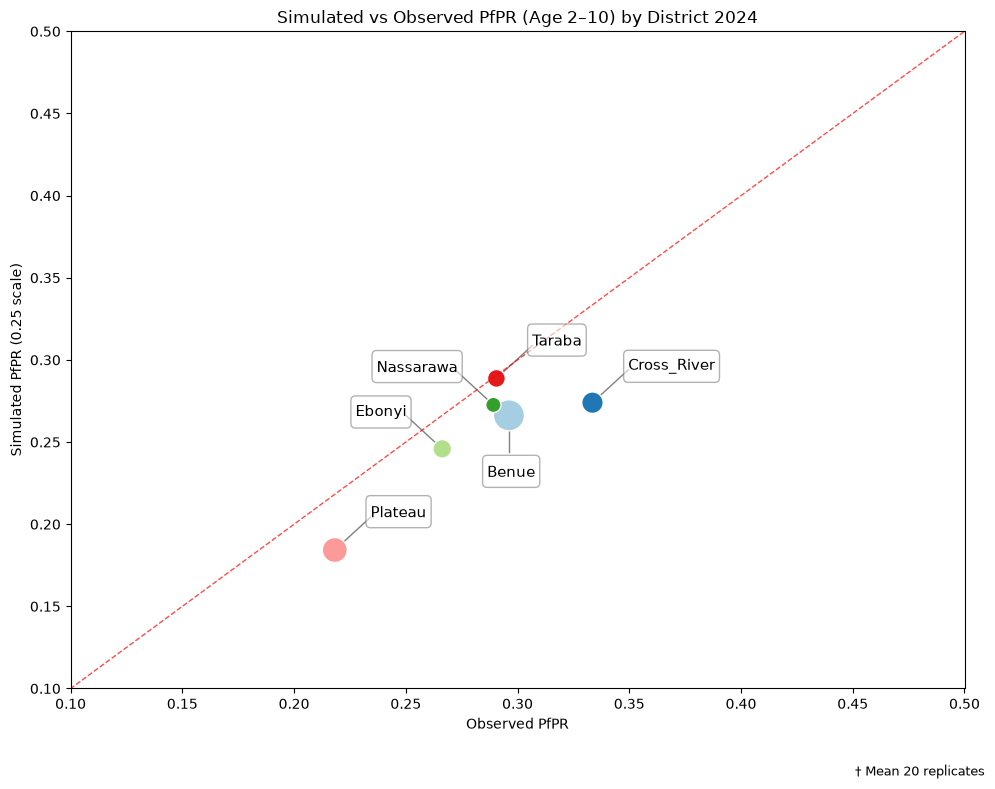

In [37]:
# ======================================================
# Figure 1: Simulated vs Observed PfPR by District
# ======================================================
fig, ax = plt.subplots(figsize=(10, 8))

d1 = compare_data[["average_OBSERVED_prevalence_2_to_10_through_calibration_year", "average_simulated_prevalence_2_to_10_through_calibration_year", "State", "average_simulated_population_through_calibration_year"]].dropna(
    subset=["average_OBSERVED_prevalence_2_to_10_through_calibration_year", "average_simulated_prevalence_2_to_10_through_calibration_year"]
)

sns.scatterplot(
    data=d1,
    x="average_OBSERVED_prevalence_2_to_10_through_calibration_year",
    y="average_simulated_prevalence_2_to_10_through_calibration_year",
    hue="State",
    size="average_simulated_population_through_calibration_year",  
    sizes=(120, 500),
    palette="Paired",
    ax=ax,
    legend=False
)

sc = ax.collections[0] if ax.collections else None

''' Use full range when trying to calibrate pipeline, narrow range yields better looking plots when finalized'''

# ax.set_xlim(0.0, 1.0)
# ax.set_ylim(0.0, 1.0)
ax.set_xlim(0.1, 0.5)
ax.set_ylim(0.1, 0.5)

span = min(ax.get_xlim()[1] - ax.get_xlim()[0], ax.get_ylim()[1] - ax.get_ylim()[0])

texts = d1["State"].astype(str).fillna("").tolist()
x = d1["average_OBSERVED_prevalence_2_to_10_through_calibration_year"].to_numpy(dtype=float)
y = d1["average_simulated_prevalence_2_to_10_through_calibration_year"].to_numpy(dtype=float)

allocate(
    ax,
    x,
    y,
    texts,
    scatter_plot=sc,
    textsize=11,
    draw_lines=True,
    linecolor="gray",
    textcolor="black",
    margin=0.02,
    min_distance=0.10 * span,
    max_distance=0.35 * span,
    nbr_candidates=3000,
    verbose=False,
    linespacing=1.5,   
    multialignment="left",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="gray",
        alpha=0.6,
    ),
)

ax.plot([0.0, 1.0], [0.0, 1.0], linestyle="--", linewidth=1, color="red", alpha=0.7)
ax.set_title(f"Simulated vs Observed PfPR (Age 2–10) by District {calibration_year}")
ax.set_xlabel("Observed PfPR")
ax.set_ylabel(f"Simulated PfPR ({population_scale_from_input_yml} scale)")

plt.tight_layout(rect=[0, 0.06, 1, 1])
fig.text(0.99, 0.02, f"$\dagger$ Mean {validation_replicates} replicates",
          ha='right', va='bottom', fontsize=9)
plt.savefig(f"{analysis_path}/Simulated_vs_Observed_PfPR_by_District_{calibration_year}.png", dpi=200, bbox_inches="tight")
plt.show()

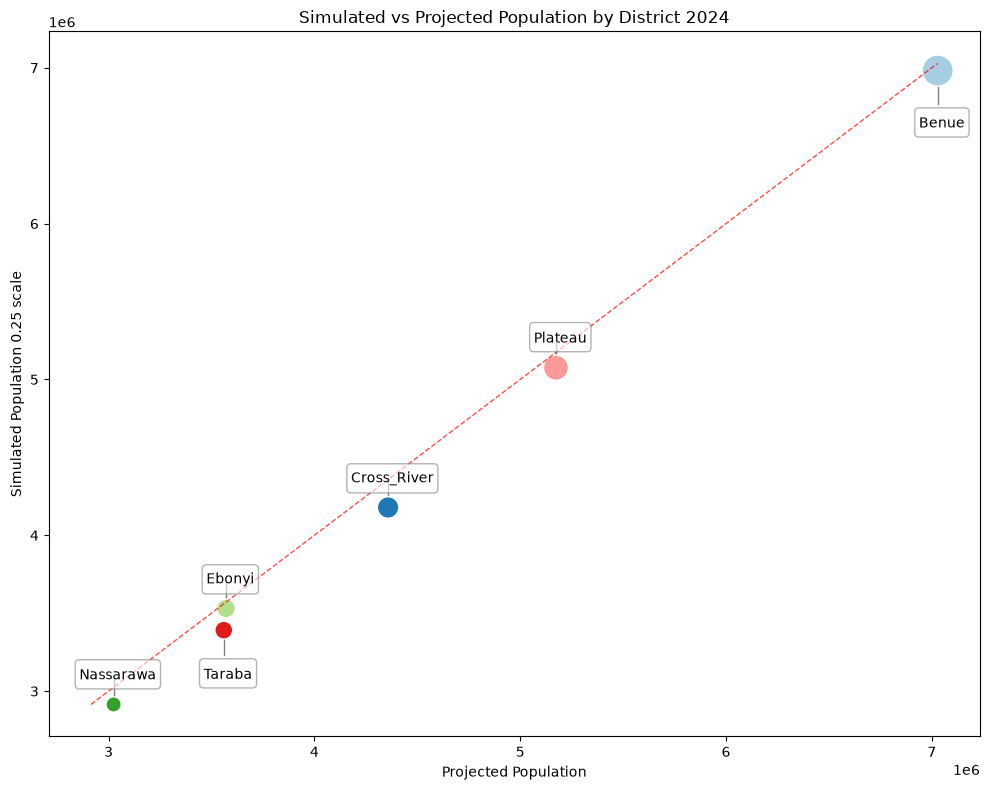

In [38]:
# ======================================================
# Figure 2: Simulated vs Projected Population by District
# ======================================================
fig, ax = plt.subplots(figsize=(10, 8))

d2 = compare_data[["population_projected_calibration_year", "average_simulated_population_through_calibration_year", "State"]].dropna(
    subset=["population_projected_calibration_year", "average_simulated_population_through_calibration_year"]
)

sns.scatterplot(
    data=d2,
    x="population_projected_calibration_year",
    y="average_simulated_population_through_calibration_year",
    hue="State",
    size="average_simulated_population_through_calibration_year",
    sizes=(120, 500),
    palette="Paired",
    ax=ax,
    legend=False
)

sc = ax.collections[0] if ax.collections else None

texts = d2["State"].astype(str).fillna("").tolist()
x = d2["population_projected_calibration_year"].to_numpy(dtype=float)
y = d2["average_simulated_population_through_calibration_year"].to_numpy(dtype=float)

allocate(
    ax,
    x,
    y,
    texts,
    scatter_plot=sc,
    textsize=10,
    draw_lines=True,
    linecolor="gray",
    textcolor="black",
    margin=0.01,
    min_distance=0.01,
    max_distance=0.08,
    nbr_candidates=300,
    verbose=False,
    linespacing=1.5,   
    multialignment="left",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="gray",
        alpha=0.6,
    ),
)

min_val = min(d2["population_projected_calibration_year"].min(), d2["average_simulated_population_through_calibration_year"].min())
max_val = max(d2["population_projected_calibration_year"].max(), d2["average_simulated_population_through_calibration_year"].max())
ax.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=1, color="red", alpha=0.7)

ax.set_title(f"Simulated vs Projected Population by District {calibration_year}")
ax.set_xlabel("Projected Population")
ax.set_ylabel(f"Simulated Population {population_scale_from_input_yml} scale")

plt.tight_layout()
plt.savefig(f"{analysis_path}/Simulated_vs_Projected_Population_by_District_{calibration_year}.png", dpi=200, bbox_inches="tight")
plt.show()

In [39]:
compare_data

,unit_id,average_simulated_prevalence_2_to_10_through_calibration_year,average_simulated_population_through_incidence_comparison_year,average_simulated_population_through_calibration_year,total_simulated_clinical_episodes_in_incidence_comparison_year,total_simulated_treatments_in_incidence_comparison_year,total_simulated_treatments_in_incidence_comparison_year_public,State,Region ID,Incidence Per Thousand Recorded in 2021,"Population (2019 estimate, from Wikipedia, National Bureau of Statistics)",Population (2020 estimate from worldpop rasters),Growth Rate (2019-2020),Population (2021 target based on worldometers birth rate and wordpop raster counts),annual_OBSERVED_clinical_episodes_incidence_comparison_year,population_projected_calibration_year,Total Cases 2024 from projected population and observed incidence,average_OBSERVED_prevalence_2_to_10_through_calibration_year,district_name
0,7,0,6666570,6982174,3512742,2111194,939481,Benue,7,257,5787706,6464378,1,6601202,1697829,7028225,1807659,0,Benue
1,9,0,4009218,4178418,2138451,1043683,464439,Cross_River,9,289,4175020,4008484,1,4093327,1182153,4358119,1258625,0,Cross River
2,11,0,3369498,3530288,1765220,1006985,448108,Ebonyi,11,372,3007155,3284316,1,3353832,1245948,3570786,1326547,0,Ebonyi
3,26,0,2798028,2914438,1483713,638420,284097,Nassarawa,26,274,2632239,2781807,1,2840686,778632,3024446,829001,0,Nassarawa
4,32,0,4852749,5074930,2932996,1091862,485879,Plateau,32,286,4400974,4758921,1,4859648,1392289,5174011,1482354,0,Plateau
5,35,0,3262501,3391309,1754702,667742,297145,Taraba,35,300,3331885,3274257,1,3343560,1002734,3559850,1067599,0,Taraba


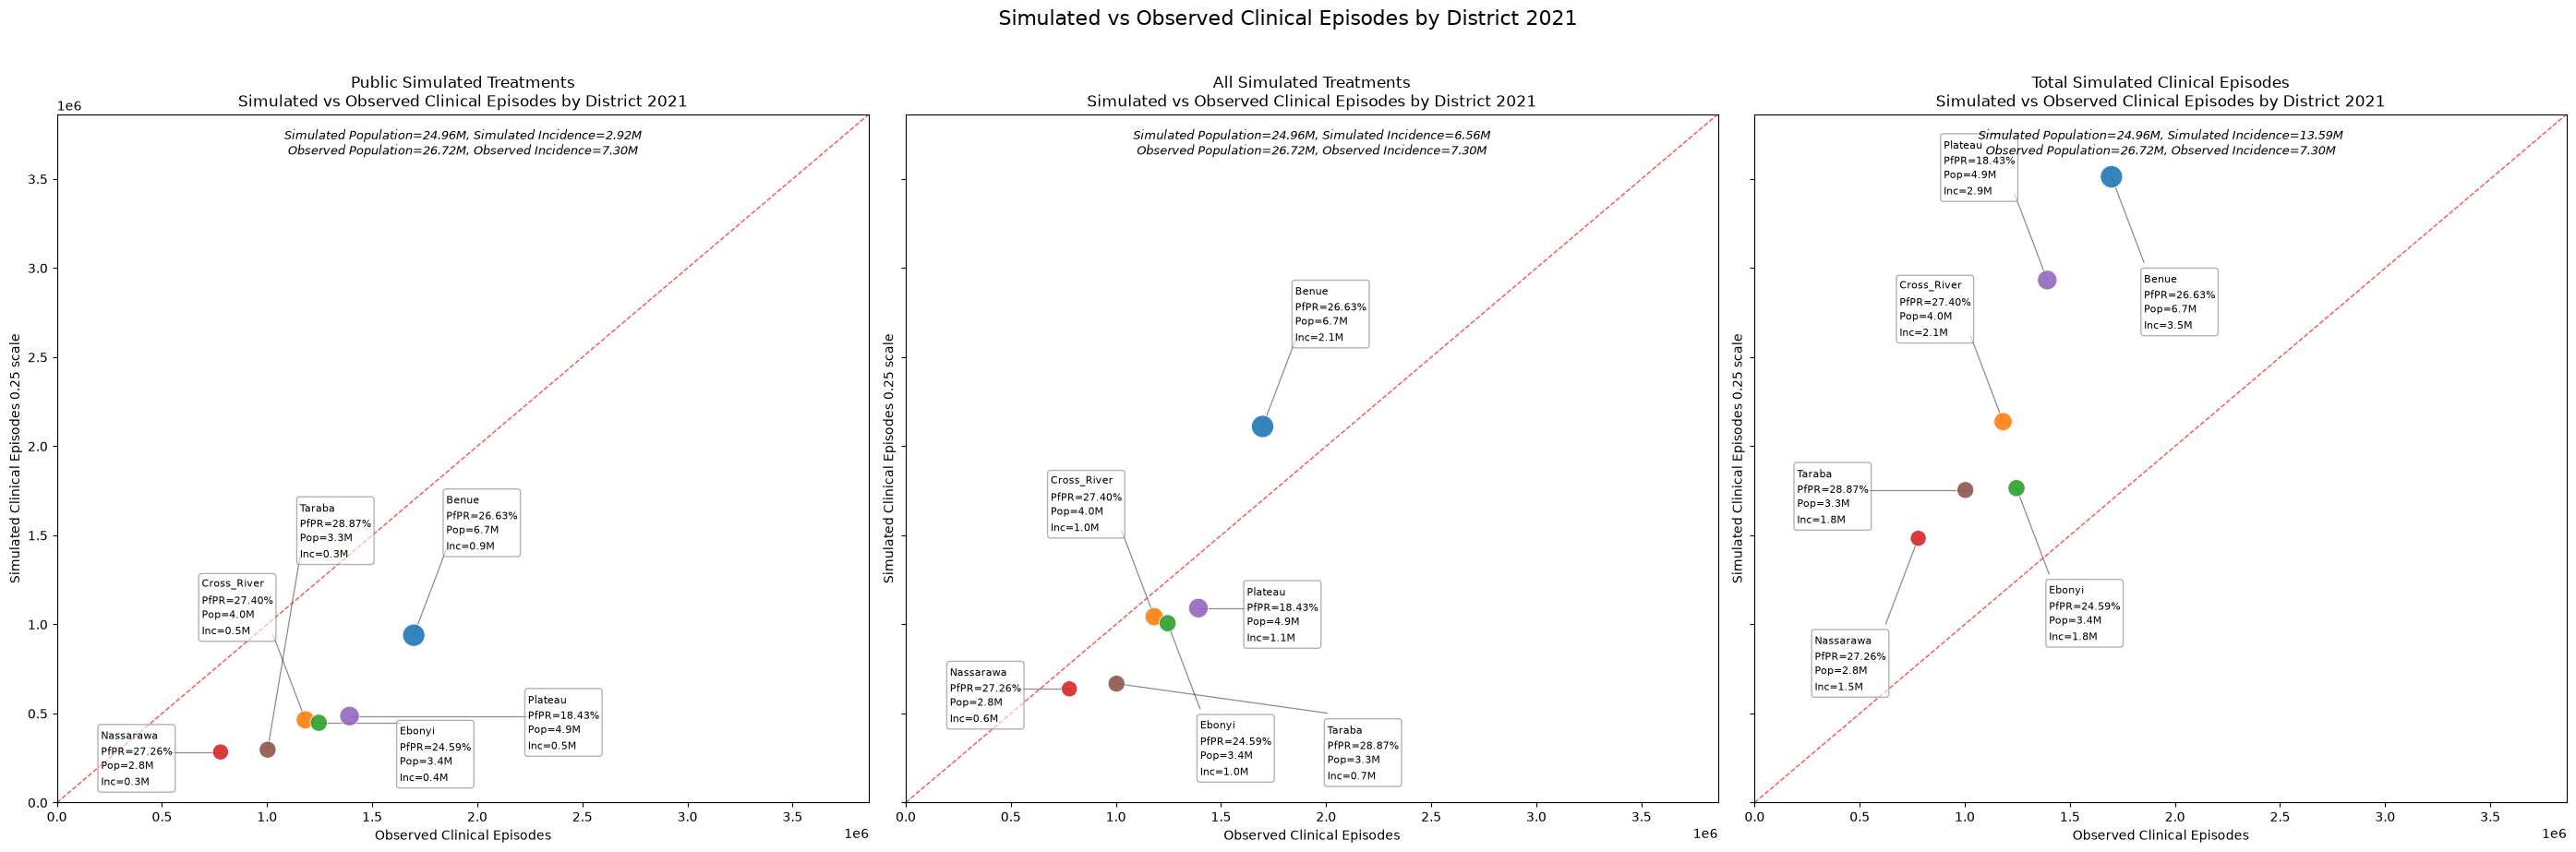

In [40]:
# ======================================================
# Figure 3: Simulated vs Observed Clinical Episodes by District
# ======================================================

fig, axes = plt.subplots(
    1, 3,
    figsize=(28, 9),
    sharex=True,
    sharey=True,
)

simulated_episode_columns = [
    "total_simulated_treatments_in_incidence_comparison_year_public",
    "total_simulated_treatments_in_incidence_comparison_year",
    "total_simulated_clinical_episodes_in_incidence_comparison_year",
]

d4 = compare_data[
    [
        "annual_OBSERVED_clinical_episodes_incidence_comparison_year",
        "total_simulated_treatments_in_incidence_comparison_year_public",
        "total_simulated_treatments_in_incidence_comparison_year",
        "total_simulated_clinical_episodes_in_incidence_comparison_year",
        "average_simulated_population_through_incidence_comparison_year",
        "State",
        "average_simulated_prevalence_2_to_10_through_calibration_year",
        "population_projected_calibration_year",
    ]
].dropna(
    subset=[
        "annual_OBSERVED_clinical_episodes_incidence_comparison_year",
        "total_simulated_treatments_in_incidence_comparison_year_public",
        "total_simulated_treatments_in_incidence_comparison_year",
        "total_simulated_clinical_episodes_in_incidence_comparison_year",
        "average_simulated_population_through_incidence_comparison_year",
        "average_simulated_prevalence_2_to_10_through_calibration_year",
        "population_projected_calibration_year",
    ]
).copy()

x = d4[
    "annual_OBSERVED_clinical_episodes_incidence_comparison_year"
].to_numpy(float)

pop = d4[
    "average_simulated_population_through_incidence_comparison_year"
].to_numpy(float)

sizes = (pop / pop.max()) * 250.0 + 50.0

districts = d4["State"].astype(str).tolist()
palette = sns.color_palette("tab10", n_colors=len(districts))
color_map = {name: palette[i] for i, name in enumerate(districts)}
colors = [color_map[name] for name in districts]

all_y_values = np.concatenate(
    [d4[column].to_numpy(float) for column in simulated_episode_columns]
)

maxv = max(np.nanmax(x), np.nanmax(all_y_values)) * 1.10

for ax, simulated_episode_column in zip(axes, simulated_episode_columns):
    y = d4[simulated_episode_column].to_numpy(float)

    total_pop_sim = d4[
        "average_simulated_population_through_incidence_comparison_year"
    ].sum()

    total_clinical_episodes_sim = d4[simulated_episode_column].sum()

    total_pop_obs = d4["population_projected_calibration_year"].sum()
    total_clinical_episodes_obs = d4[
        "annual_OBSERVED_clinical_episodes_incidence_comparison_year"
    ].sum()

    texts = []
    for _, row in d4.iterrows():
        name = str(row["State"])
        pfpr = row["average_simulated_prevalence_2_to_10_through_calibration_year"]
        population = row["average_simulated_population_through_incidence_comparison_year"]
        cases = row[simulated_episode_column]

        label = (
            f"{name}\n"
            f"PfPR={pfpr * 100:.2f}%\n"
            f"Pop={population / 1e6:.1f}M\n"
            f"Inc={cases / 1e6:.1f}M"
        )
        texts.append(label)

    sc = ax.scatter(
        x,
        y,
        s=sizes,
        c=colors,
        alpha=0.9,
        edgecolors="white",
        linewidths=0.6,
        zorder=2,
    )

    ax.set_xlim(0, maxv)
    ax.set_ylim(0, maxv)

    linecolor = [(0, 0, 0, 0.45)] * len(x)

    allocate(
        ax,
        x,
        y,
        texts,
        scatter_plot=sc,
        textsize=8,
        draw_lines=True,
        draw_all=True,
        linecolor=linecolor,
        linewidth=0.9,
        margin=0.03,
        min_distance=0.04,
        max_distance=0.38,
        nbr_candidates=5000,
        verbose=False,
        linespacing=1.5,
        multialignment="left",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="gray",
            alpha=0.6,
        ),
    )

    ax.plot(
        ax.get_xlim(),
        ax.get_ylim(),
        color="red",
        linestyle="--",
        linewidth=1,
        zorder=1,
        alpha=0.7,
    )

    ax.set_xlabel("Observed Clinical Episodes")
    ax.set_ylabel(f"Simulated Clinical Episodes {population_scale_from_input_yml} scale")

    if simulated_episode_column == "total_simulated_treatments_in_incidence_comparison_year_public":
        title = "Public Simulated Treatments"
    elif simulated_episode_column == "total_simulated_treatments_in_incidence_comparison_year":
        title = "All Simulated Treatments"
    else:
        title = "Total Simulated Clinical Episodes"

    ax.set_title(
        f"{title}\n"
        f"Simulated vs Observed Clinical Episodes by District {incidence_comparison_year}"
    )

    ax.text(
        0.5,
        0.98,
        (
            f"Simulated Population={total_pop_sim / 1e6:.2f}M, "
            f"Simulated Incidence={total_clinical_episodes_sim / 1e6:.2f}M\n"
            f"Observed Population={total_pop_obs / 1e6:.2f}M, "
            f"Observed Incidence={total_clinical_episodes_obs / 1e6:.2f}M"
        ),
        transform=ax.transAxes,
        fontsize=9,
        color="black",
        style="italic",
        ha="center",
        va="top",
    )

fig.suptitle(
    f"Simulated vs Observed Clinical Episodes by District {incidence_comparison_year}",
    fontsize=16,
    y=1.02,
)

plt.tight_layout()
plt.savefig(
    f"{analysis_path}/Simulated_vs_Observed_Clinical_Episodes_{incidence_comparison_year}_3subplots.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

In [41]:
d4

,annual_OBSERVED_clinical_episodes_incidence_comparison_year,total_simulated_treatments_in_incidence_comparison_year_public,total_simulated_treatments_in_incidence_comparison_year,total_simulated_clinical_episodes_in_incidence_comparison_year,average_simulated_population_through_incidence_comparison_year,State,average_simulated_prevalence_2_to_10_through_calibration_year,population_projected_calibration_year
0,1697829,939481,2111194,3512742,6666570,Benue,0,7028225
1,1182153,464439,1043683,2138451,4009218,Cross_River,0,4358119
2,1245948,448108,1006985,1765220,3369498,Ebonyi,0,3570786
3,778632,284097,638420,1483713,2798028,Nassarawa,0,3024446
4,1392289,485879,1091862,2932996,4852749,Plateau,0,5174011
5,1002734,297145,667742,1754702,3262501,Taraba,0,3559850


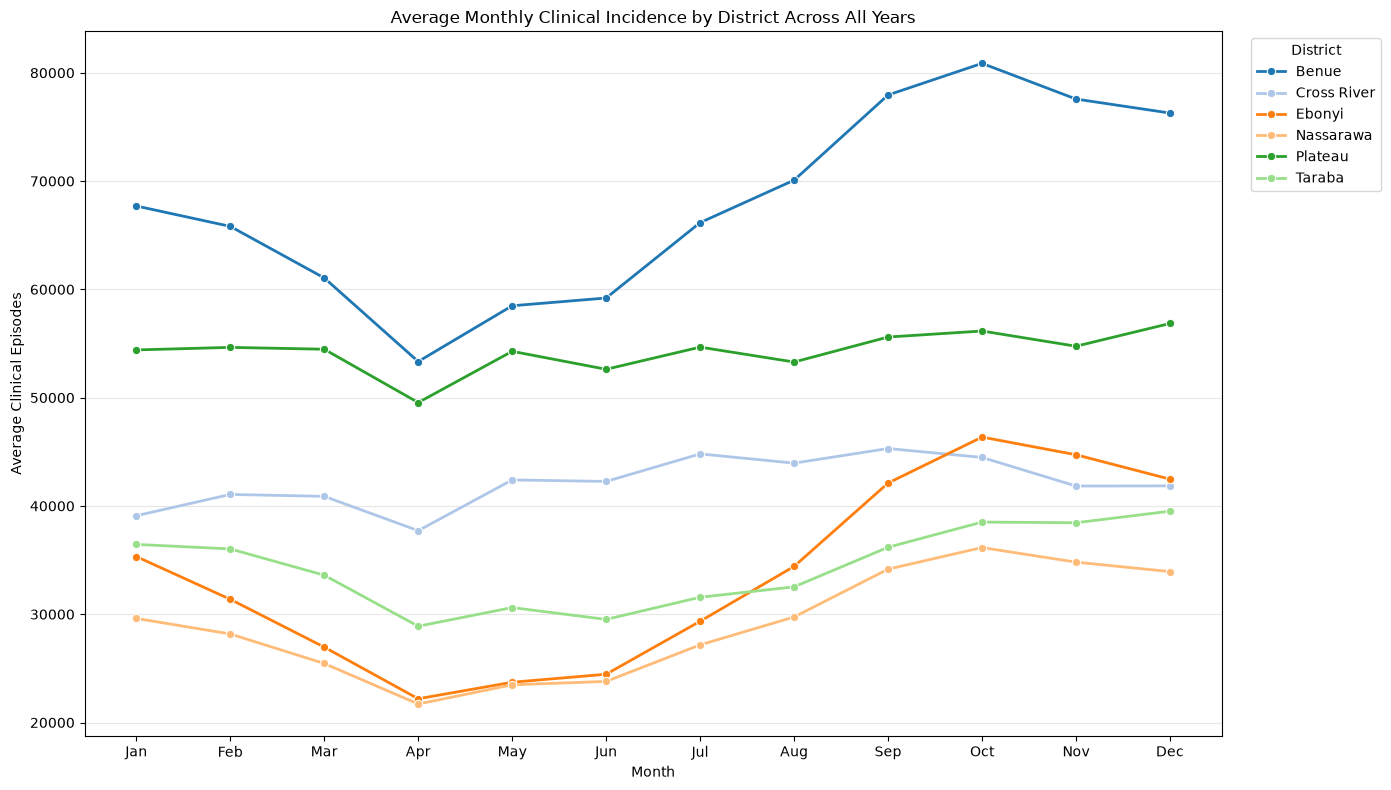

In [42]:
# Average monthly clinical incidence by district across all years

monthly_incidence = agg_clinical_episodes.copy()

# Identify replicate columns and calculate mean incidence across replicates
replicate_columns = [
    column
    for column in monthly_incidence.columns
    if column not in ["monthly_data_id", "unit_id"]
]

monthly_incidence["monthly_incidence"] = monthly_incidence[replicate_columns].mean(axis=1)

# Drop first two years
monthly_incidence = monthly_incidence.loc[monthly_incidence["monthly_data_id"] > 24].copy()

# Drop last year
monthly_incidence = monthly_incidence.loc[monthly_incidence["monthly_data_id"] < (incidence_comparison_end_month - 12)].copy()

# Convert the unit_id to the old district ID using the mapping
monthly_incidence["unit_id"] = monthly_incidence["unit_id"].map(old_to_new_district_id_mapping.set_index("new_district_id")["old_district_id"])

# Convert the simulation month ID to month of year
monthly_incidence["month_number"] = (
    monthly_incidence["monthly_data_id"] % 12
)

month_names = {
    0: "Jan",
    1: "Feb",
    2: "Mar",
    3: "Apr",
    4: "May",
    5: "Jun",
    6: "Jul",
    7: "Aug",
    8: "Sep",
    9: "Oct",
    10: "Nov",
    11: "Dec",
}

monthly_incidence["month"] = monthly_incidence["month_number"].map(month_names)

# Add district names
if "district_name" in district_mapping.columns:
    monthly_incidence = monthly_incidence.merge(
        district_mapping[["unit_id", "district_name"]],
        on="unit_id",
        how="left",
    )
    monthly_incidence["district"] = monthly_incidence["district_name"].fillna(
        monthly_incidence["unit_id"].astype(str)
    )
else:
    monthly_incidence["district"] = monthly_incidence["unit_id"].astype(str)

# Average incidence for each district and calendar month across all simulation years
average_monthly_incidence = (
    monthly_incidence.groupby(
        ["month_number", "month", "district"],
        as_index=False,
    )["monthly_incidence"]
    .mean()
    .sort_values(["month_number", "district"])
)

# Plot all districts on one chart
plt.figure(figsize=(14, 8))

sns.lineplot(
    data=average_monthly_incidence,
    x="month",
    y="monthly_incidence",
    hue="district",
    marker="o",
    linewidth=2,
    palette="tab20",
    legend="brief"
)

plt.title("Average Monthly Clinical Incidence by District Across All Years")
plt.xlabel("Month")
plt.ylabel("Average Clinical Episodes")
plt.xticks(
    ticks=range(12),
    labels=list(month_names.values()),
)
plt.legend(
    title="District",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    f"{analysis_path}/Average_Monthly_Incidence_by_District_All_Years.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

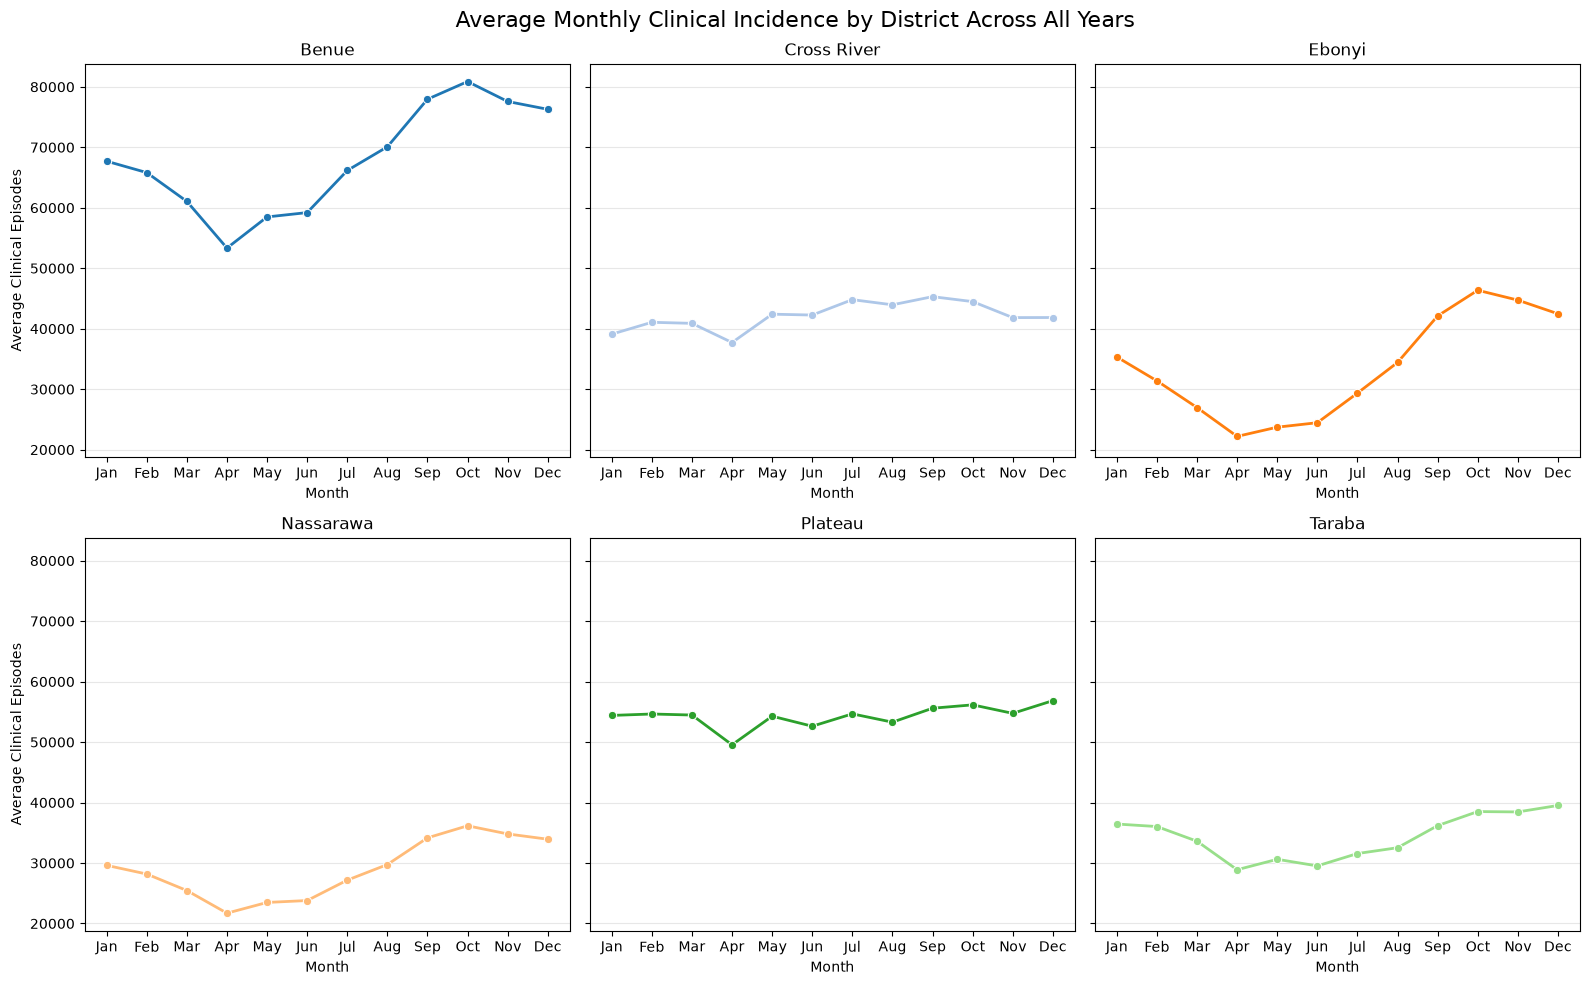

In [43]:
# Average monthly clinical incidence by district across all years

monthly_incidence = agg_clinical_episodes.copy()

# Identify replicate columns and calculate mean incidence across replicates
replicate_columns = [
    column
    for column in monthly_incidence.columns
    if column not in ["monthly_data_id", "unit_id"]
]

monthly_incidence["monthly_incidence"] = monthly_incidence[
    replicate_columns
].mean(axis=1)

# Drop first two years
monthly_incidence = monthly_incidence.loc[monthly_incidence["monthly_data_id"] > 24].copy()

# Drop last year
monthly_incidence = monthly_incidence.loc[monthly_incidence["monthly_data_id"] < (incidence_comparison_end_month - 12)].copy()

# Convert the unit_id to the old district ID using the mapping
monthly_incidence["unit_id"] = monthly_incidence["unit_id"].map(old_to_new_district_id_mapping.set_index("new_district_id")["old_district_id"])


# Convert the simulation month ID to month of year
monthly_incidence["month_number"] = (
    monthly_incidence["monthly_data_id"] % 12
)

month_names = {
    0: "Jan",
    1: "Feb",
    2: "Mar",
    3: "Apr",
    4: "May",
    5: "Jun",
    6: "Jul",
    7: "Aug",
    8: "Sep",
    9: "Oct",
    10: "Nov",
    11: "Dec",
}

monthly_incidence["month"] = monthly_incidence["month_number"].map(
    month_names
)

# Add district names
if "district_name" in district_mapping.columns:
    monthly_incidence = monthly_incidence.merge(
        district_mapping[["unit_id", "district_name"]],
        on="unit_id",
        how="left",
    )

    monthly_incidence["district"] = monthly_incidence[
        "district_name"
    ].fillna(monthly_incidence["unit_id"].astype(str))
else:
    monthly_incidence["district"] = monthly_incidence["unit_id"].astype(
        str
    )

# Average incidence for each district and calendar month
average_monthly_incidence = (
    monthly_incidence.groupby(
        ["month_number", "month", "district"],
        as_index=False,
    )["monthly_incidence"]
    .mean()
    .sort_values(["month_number", "district"])
)

# Get districts and assign each district a consistent color
districts = sorted(
    average_monthly_incidence["district"].unique()
)

palette = dict(
    zip(
        districts,
        sns.color_palette("tab20", n_colors=len(districts)),
    )
)

# Configure subplot layout
ncols = 3
nrows = math.ceil(len(districts) / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(16, 5 * nrows),
    sharex=False,
    sharey=True,
)

# Ensure axes is always iterable
axes = np.atleast_1d(axes).flatten()

# Plot each district in its own subplot
for ax, district in zip(axes, districts):
    district_data = average_monthly_incidence.loc[
        average_monthly_incidence["district"] == district
    ].sort_values("month_number")

    sns.lineplot(
        data=district_data,
        x="month_number",
        y="monthly_incidence",
        marker="o",
        linewidth=2,
        color=palette[district],
        ax=ax,
    )

    ax.set_title(str(district))
    ax.set_xlabel("Month")
    ax.set_ylabel("Average Clinical Episodes")

    # Show month tick labels on every subplot
    ax.set_xticks(range(12))
    ax.set_xticklabels(list(month_names.values()))

    # Independent y-axis scaling for every subplot
    ax.grid(axis="y", alpha=0.3)

# Remove unused subplots
for ax in axes[len(districts):]:
    fig.delaxes(ax)

fig.suptitle(
    "Average Monthly Clinical Incidence by District Across All Years",
    fontsize=16,
)

plt.tight_layout()

plt.savefig(
    f"{analysis_path}/Average_Monthly_Incidence_by_District_Separate_District_plots_All_Years.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

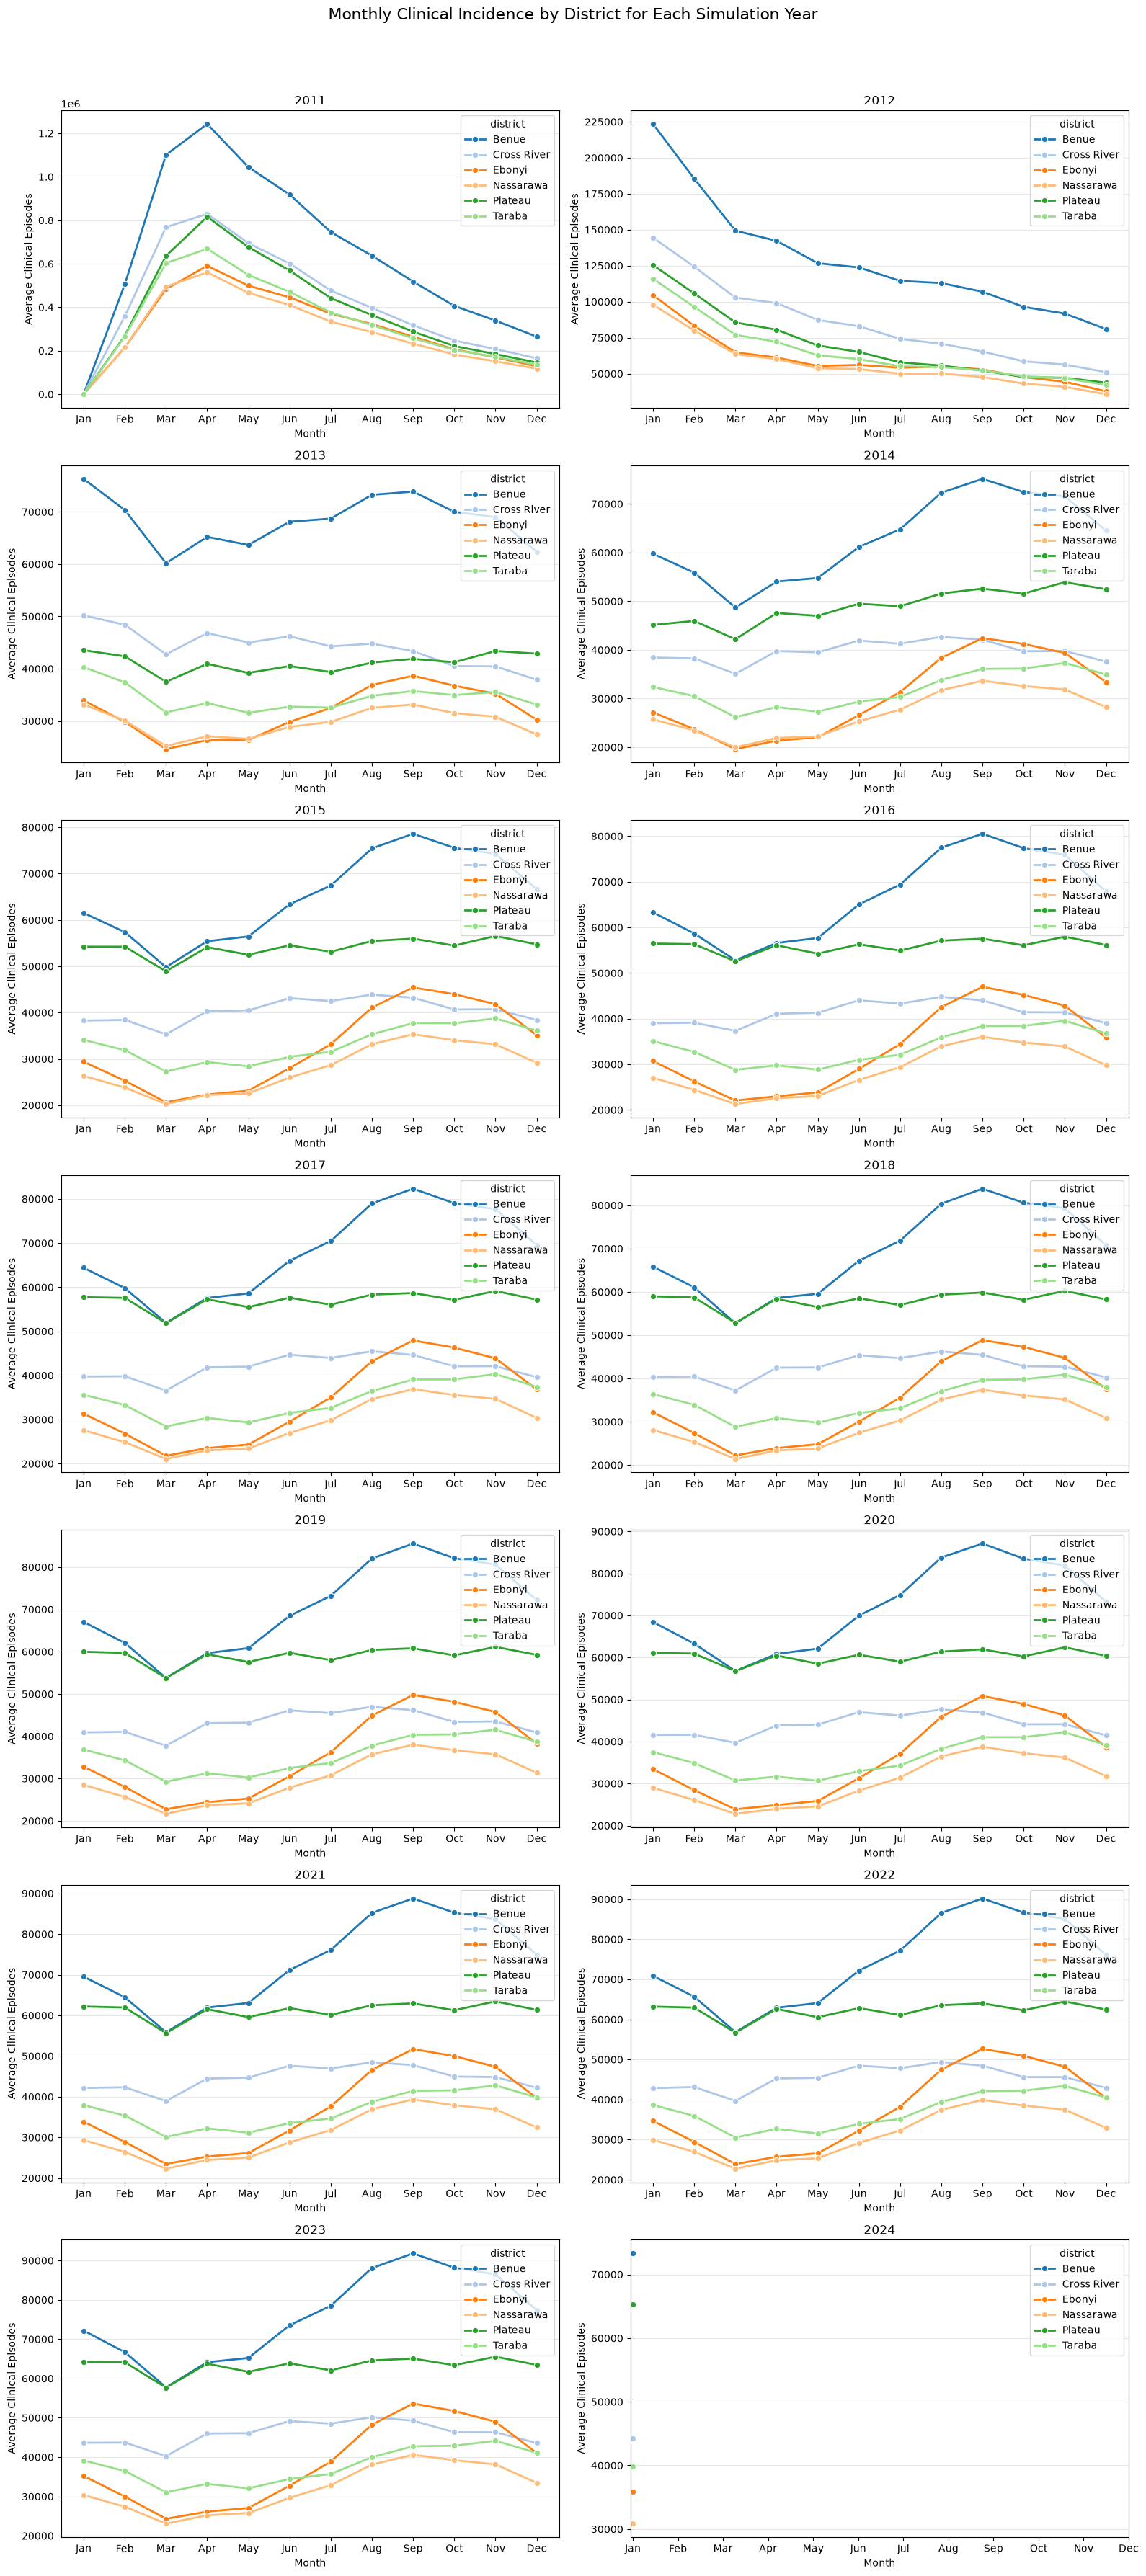

In [44]:
# Monthly clinical incidence by district, with one subplot per simulation year

monthly_incidence = agg_clinical_episodes.copy()

# Identify replicate columns and calculate mean incidence across replicates
replicate_columns = [
    column
    for column in monthly_incidence.columns
    if column not in ["monthly_data_id", "unit_id"]
]

# Convert unit ids
monthly_incidence["unit_id"] = monthly_incidence["unit_id"].map(old_to_new_district_id_mapping.set_index("new_district_id")["old_district_id"])

monthly_incidence["monthly_incidence"] = monthly_incidence[
    replicate_columns
].mean(axis=1)

# Assuming monthly_data_id starts at 1:
# Month 1 = January, month 12 = December, month 13 = January of year 2
monthly_incidence["year"] = (
    (monthly_incidence["monthly_data_id"] - 1) // 12
) + 1

monthly_incidence["month_number"] = (
    monthly_incidence["monthly_data_id"] - 1
) % 12

month_names = {
    0: "Jan",
    1: "Feb",
    2: "Mar",
    3: "Apr",
    4: "May",
    5: "Jun",
    6: "Jul",
    7: "Aug",
    8: "Sep",
    9: "Oct",
    10: "Nov",
    11: "Dec",
}

monthly_incidence["month"] = monthly_incidence["month_number"].map(
    month_names
)

# Add district names
if "district_name" in district_mapping.columns:
    monthly_incidence = monthly_incidence.merge(
        district_mapping[["unit_id", "district_name"]],
        on="unit_id",
        how="left",
    )

    monthly_incidence["district"] = monthly_incidence[
        "district_name"
    ].fillna(monthly_incidence["unit_id"].astype(str))
else:
    monthly_incidence["district"] = monthly_incidence["unit_id"].astype(str)

# Create one subplot for each simulation year
years = sorted(monthly_incidence["year"].unique())

ncols = 2
nrows = math.ceil(len(years) / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(16, 5 * nrows),
    sharex=False,
    sharey=False,
)

# Ensure axes is always iterable
axes = np.atleast_1d(axes).flatten()

# Use the same colors for districts across all subplots
districts = sorted(monthly_incidence["district"].unique())
palette = dict(
    zip(
        districts,
        sns.color_palette("tab20", n_colors=len(districts)),
    )
)

for ax, year in zip(axes, years):
    year_data = monthly_incidence.loc[
        monthly_incidence["year"] == year
    ].sort_values(["month_number", "district"])

    sns.lineplot(
        data=year_data,
        x="month_number",
        y="monthly_incidence",
        hue="district",
        hue_order=districts,
        marker="o",
        linewidth=2,
        palette=palette,
        ax=ax,
        legend=True,
    )

    ax.set_title(initial_year +year - 1)
    ax.set_xlabel("Month")
    ax.set_ylabel("Average Clinical Episodes")
    ax.set_xticks(range(12))
    ax.set_xticklabels(list(month_names.values()))
    ax.grid(axis="y", alpha=0.3)

# Remove unused subplots
for ax in axes[len(years):]:
    fig.delaxes(ax)

# Create a single legend for the entire figure
handles, labels = axes[0].get_legend_handles_labels()

# fig.legend(
#     handles,
#     labels,
#     title="District",
#     bbox_to_anchor=(1.02, 1),
#     loc="upper left",
# )

fig.suptitle(
    "Monthly Clinical Incidence by District for Each Simulation Year",
    fontsize=16,
    y=1.02,
)

plt.tight_layout()

plt.savefig(
    f"{analysis_path}/Monthly_Incidence_by_District_by_Year.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

In [45]:
agg_clinical_episodes.head(50)

,monthly_data_id,unit_id,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2,clinical_episodes_3,clinical_episodes_4,clinical_episodes_5,clinical_episodes_6,clinical_episodes_7,...,clinical_episodes_10,clinical_episodes_11,clinical_episodes_12,clinical_episodes_13,clinical_episodes_14,clinical_episodes_15,clinical_episodes_16,clinical_episodes_17,clinical_episodes_18,clinical_episodes_19
0,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,4,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,5,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,1,6,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,2,1,506077,505639,506230,506052,505804,507118,507707,508552,...,504252,505114,507095,505928,505708,507818,503635,507308,507183,505241
7,2,2,358868,358620,357480,359599,359193,358785,358134,357278,...,357900,358401,359362,358954,359189,358973,357404,357752,358425,359012
8,2,3,214883,214820,215103,215288,216483,215109,215297,214332,...,214844,214142,214256,216000,214568,215014,215022,214692,214872,215981
9,2,4,215793,215030,215453,216293,216945,215156,215950,213781,...,214672,216228,213876,216411,214208,216191,214385,215704,216187,215569
